# 06 · GSE65391 · RNA_array · module–trait associations

Reads `modules.rds`, `wgcna_input.rds`, `metadata.rds`. Writes the end products
`data/run_artifacts/GSE65391/module_traits.csv` and `clinical_dictionary.csv`.

**Samples:** the 157 first visits used to build the modules.

**Traits.** Every clinical variable GEO records at the first visit that is numeric or two-valued:

| trait | coding |
|---|---|
| sledai | score |
| stage | SLEDAI category as 0 (none) to 4 (very high) |
| nephritis_any | 1 if a nephritis class is recorded other than NoLN, 0 if NoLN, missing otherwise |
| nephritis_proliferative | 1 if Prolif or Proli+Membr, 0 if any other recorded class or NoLN |
| age | years |
| female | 1 female, 0 male |
| c3, c4 | as recorded |
| ds_dna_log10 | log10 of anti-dsDNA; the raw values span 0.05 to 5,531 |
| wbc, neutrophil_count, lymphocyte_count, platelet_count | as recorded |
| oral_steroids, iv_steroids, mycophenolate, hydroxychloroquine, cyclophosphamide | 1 if the category is 1 |

**Test.** For each module eigengene and each trait: Pearson correlation r on the samples where the
trait is recorded (for a 0/1 trait this is the point-biserial correlation, equivalent to a t-test).
p from `cor.test`. BH (Benjamini–Hochberg) q across all module × trait tests. **A finding** is
q < 0.05.

In [1]:
source("../src/paths.R")
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
m    <- readRDS(art("GSE65391", "metadata.rds"))[rownames(w$datExpr), ]
ME   <- mods$MEs[, colnames(mods$MEs) != "MEgrey"]
stopifnot(identical(rownames(ME), rownames(m)))
dim(ME)

[1] 157  16

In [2]:
traits <- data.frame(
  sledai = m$sledai,
  stage = as.numeric(m$stage) - 1,
  nephritis_any = ifelse(is.na(m$nephritis_class), NA, as.numeric(m$nephritis_class != "NoLN")),
  nephritis_proliferative = ifelse(is.na(m$nephritis_class), NA, as.numeric(m$nephritis_class %in% c("Prolif", "Proli+Membr"))),
  age = m$age, female = as.numeric(m$sex == "F"),
  c3 = m$c3, c4 = m$c4, ds_dna_log10 = log10(m$ds_dna),
  wbc = m$wbc, neutrophil_count = m$neutrophil_count, lymphocyte_count = m$lymphocyte_count,
  platelet_count = m$platelet_count,
  oral_steroids = m$oral_steroids, iv_steroids = m$iv_steroids, mycophenolate = m$mycophenolate,
  hydroxychloroquine = m$hydroxychloroquine, cyclophosphamide = m$cyclophosphamide,
  row.names = rownames(m))
data.frame(recorded = colSums(!is.na(traits)),
           summary = sapply(traits, function(v) if (all(v %in% c(0, 1, NA))) paste0(sum(v == 1, na.rm = TRUE), " of ", sum(!is.na(v)), " = 1")
                                                 else sprintf("median %.2f", median(v, na.rm = TRUE))))

,recorded,summary
,<dbl>,<chr>
sledai,157,median 6.00
stage,157,median 2.00
nephritis_any,98,33 of 98 = 1
nephritis_proliferative,98,24 of 98 = 1
age,157,median 14.38
female,157,136 of 157 = 1
c3,149,median 96.00
c4,148,median 14.50
ds_dna_log10,90,median 1.43


In [3]:
res <- do.call(rbind, lapply(colnames(ME), function(me) do.call(rbind, lapply(colnames(traits), function(tr) {
  ok <- !is.na(traits[[tr]])
  ct <- cor.test(ME[ok, me], traits[ok, tr])
  data.frame(module = sub("^ME", "", me), trait = tr, n = sum(ok), r = unname(ct$estimate), p = ct$p.value)
}))))
res$q <- p.adjust(res$p, "BH")
c(tests = nrow(res), q_below_0.05 = sum(res$q < 0.05))
res_sig <- res[res$q < 0.05, ]; res_sig[order(res_sig$q), c("module", "trait", "n", "r", "q")]

tests q_below_0.05 
         288           55

,module,trait,n,r,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
65,blue,neutrophil_count,138,0.6086583,6.879385e-13
281,turquoise,neutrophil_count,138,-0.5509620,3.637449e-10
227,red,neutrophil_count,138,-0.5132741,1.168515e-08
2,pink,stage,157,0.4751146,2.325820e-08
187,greenyellow,c3,149,-0.4792743,3.609454e-08
64,blue,wbc,143,0.4757248,9.213505e-08
1,pink,sledai,157,0.4455251,2.059638e-07
49,tan,platelet_count,148,0.4515229,3.030828e-07
83,lightcyan,neutrophil_count,138,0.4499521,9.863032e-07


**Result.** 288 tests (16 modules × 18 traits); 55 with q < 0.05. The strongest:
- blue with neutrophil count, r = 0.61;
- pink (interferon) with stage, r = 0.48; with SLEDAI, r = 0.45; with nephritis, r = 0.37 (n = 98);
  with C3, r = −0.34;
- greenyellow (plasma cell) with C3, r = −0.48; with C4, r = −0.43; with SLEDAI, r = 0.39;
- tan (platelet) with platelet count, r = 0.45;
- lightcyan (neutrophil granule) with neutrophil count, r = 0.45.

The same table as a heatmap: Pearson r, with * for q < 0.05.

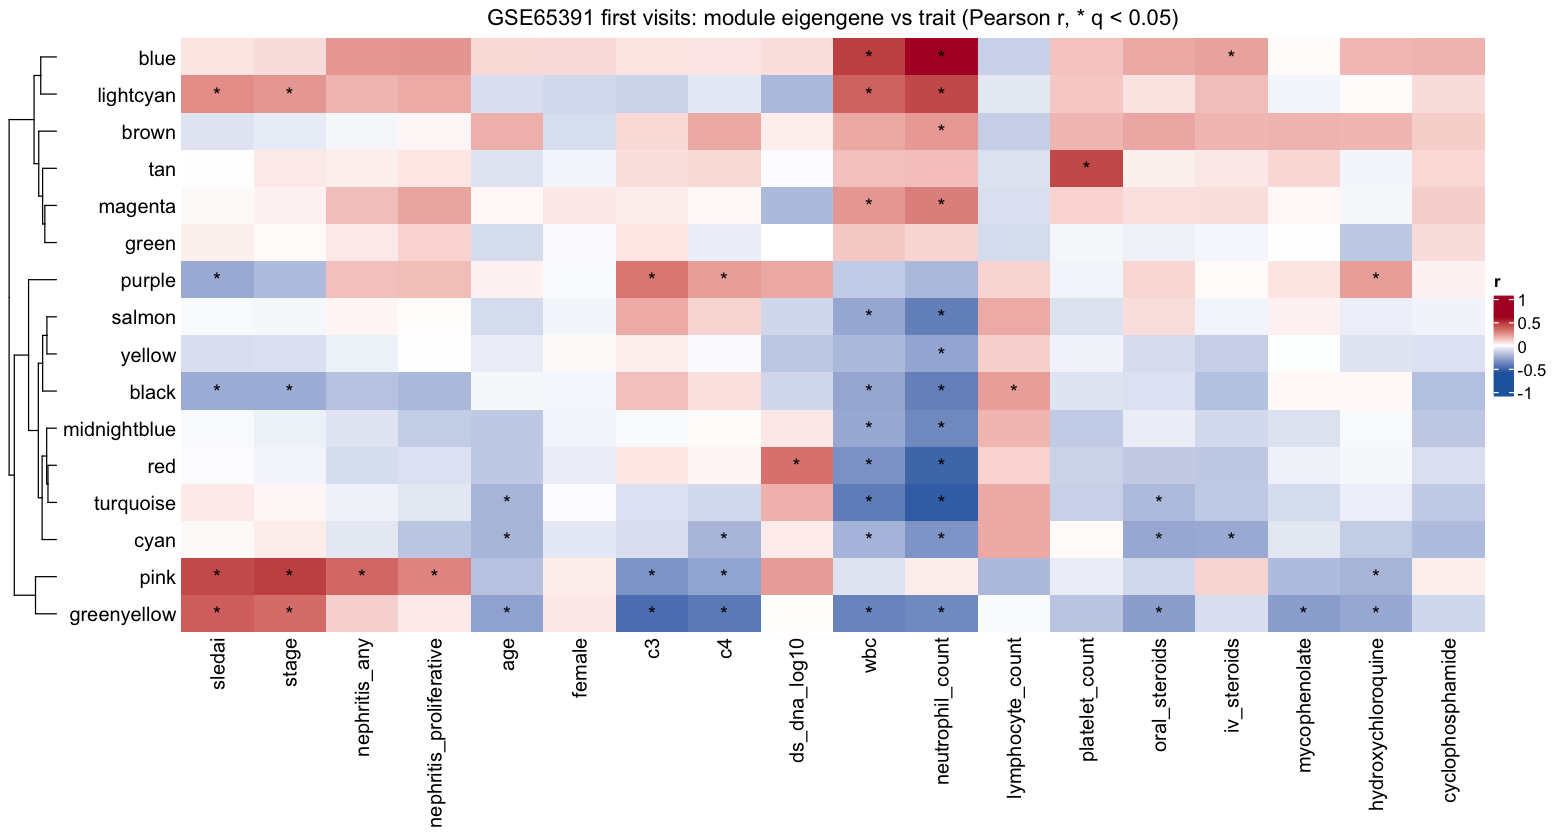

In [4]:
suppressMessages({library(ComplexHeatmap); library(circlize)})
R <- xtabs(r ~ module + trait, res); Q <- xtabs(q ~ module + trait, res)
R <- R[, colnames(traits)]; Q <- Q[, colnames(traits)]
options(repr.plot.width = 13, repr.plot.height = 7)
Heatmap(unclass(R), name = "r", col = colorRamp2(c(-0.6, 0, 0.6), c("#2166AC", "white", "#B2182B")),
        cluster_columns = FALSE, row_names_side = "left",
        cell_fun = function(j, i, x, y, w, h, f) if (Q[i, j] < 0.05) grid.text("*", x, y),
        column_title = "GSE65391 first visits: module eigengene vs trait (Pearson r, * q < 0.05)")

**End products.** The module–trait table carries n and r for every test. Fisher z = atanh(r) with
standard error 1/√(n − 3) is what the federation notebook combines across studies.

In [5]:
res$fisher_z <- atanh(res$r); res$se <- 1 / sqrt(res$n - 3)
write.csv(res, art("GSE65391", "module_traits.csv"), row.names = FALSE)
dict <- data.frame(study = "GSE65391", trait = colnames(traits), recorded = colSums(!is.na(traits)),
                   binary = sapply(traits, function(v) all(v %in% c(0, 1, NA))), row.names = NULL)
write.csv(dict, art("GSE65391", "clinical_dictionary.csv"), row.names = FALSE)
dict

study,trait,recorded,binary
<chr>,<chr>,<dbl>,<lgl>
GSE65391,sledai,157,FALSE
GSE65391,stage,157,FALSE
GSE65391,nephritis_any,98,TRUE
GSE65391,nephritis_proliferative,98,TRUE
GSE65391,age,157,FALSE
GSE65391,female,157,TRUE
GSE65391,c3,149,FALSE
GSE65391,c4,148,FALSE
GSE65391,ds_dna_log10,90,FALSE
